# Dataset Audio Length Analysis

Traverses all audio files in both the **Training** and **Testing** datasets to perfectly understand their duration distribution.
This is absolutely crucial for deciding whether 3 seconds vs 5 seconds is the optimal cropping window.

---
## 1. Paths & Imports

In [1]:
import os
import glob
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

TRAIN_ROOT = "/kaggle/input/datasets/tahmidulislamomi/ml-project-openslr-dataset/train-clean-100/train-clean-100"
TEST_ROOT  = "/kaggle/input/datasets/tahmidulislamomi/ml-project-testing-dataset/test-clean"

print("Train Dir:", TRAIN_ROOT)
print("Test Dir: ", TEST_ROOT)

Train Dir: /kaggle/input/datasets/tahmidulislamomi/ml-project-openslr-dataset/train-clean-100/train-clean-100
Test Dir:  /kaggle/input/datasets/tahmidulislamomi/ml-project-testing-dataset/test-clean


## 2. Fast File Traversal & Duration Calculation

In [2]:
def get_duration(file_path):
    try:
        # librosa.get_duration is extremely fast as it only reads the header
        return librosa.get_duration(filename=file_path)
    except:
        return None

def analyze_directory(root_dir, name="Dataset"):
    print(f"\nScanning {name}...")
    
    # 1. Find all .flac or .wav files
    all_files = glob.glob(os.path.join(root_dir, "**", "*.flac"), recursive=True)
    all_files += glob.glob(os.path.join(root_dir, "**", "*.wav"), recursive=True)
    print(f"Found {len(all_files):,} audio files.")
    
    if len(all_files) == 0:
        return []

    # 2. Extract durations using multi-threading for speed
    durations = []
    with ThreadPoolExecutor(max_workers=8) as executor:
        results = list(tqdm(executor.map(get_duration, all_files), total=len(all_files), desc="Calculating lengths"))
    
    # Remove any failures
    durations = [d for d in results if d is not None]
    
    # 3. Print Stats
    durations_np = np.array(durations)
    print(f"\n--- {name} Statistics ---")
    print(f"Minimum Length: {np.min(durations_np):.2f} seconds")
    print(f"Maximum Length: {np.max(durations_np):.2f} seconds")
    print(f"Average Length: {np.mean(durations_np):.2f} seconds")
    print(f"Median Length : {np.median(durations_np):.2f} seconds")
    print("-" * 25)
    
    return durations_np

## 3. Run Analysis on Training Set

In [3]:
train_durations = analyze_directory(TRAIN_ROOT, "Training Set")


Scanning Training Set...
Found 28,539 audio files.


Calculating lengths:   0%|          | 0/28539 [00:00<?, ?it/s]/tmp/ipykernel_24/3923184714.py:4: FutureWarning: get_duration() keyword argument 'filename' has been renamed to 'path' in version 0.10.0.
	This alias will be removed in version 1.0.
  return librosa.get_duration(filename=file_path)
Calculating lengths: 100%|██████████| 28539/28539 [01:09<00:00, 409.37it/s]


--- Training Set Statistics ---
Minimum Length: 1.41 seconds
Maximum Length: 24.52 seconds
Average Length: 12.69 seconds
Median Length : 13.99 seconds
-------------------------


## 4. Run Analysis on Testing Set

In [4]:
test_durations = analyze_directory(TEST_ROOT, "Testing Set")


Scanning Testing Set...


/tmp/ipykernel_24/3923184714.py:4: FutureWarning: get_duration() keyword argument 'filename' has been renamed to 'path' in version 0.10.0.
	This alias will be removed in version 1.0.
  return librosa.get_duration(filename=file_path)


Found 2,620 audio files.


Calculating lengths: 100%|██████████| 2620/2620 [00:05<00:00, 456.59it/s]


--- Testing Set Statistics ---
Minimum Length: 1.28 seconds
Maximum Length: 34.95 seconds
Average Length: 7.42 seconds
Median Length : 5.79 seconds
-------------------------


## 5. Visualising the Distributions

Plots side-by-side histograms to visualize the spread of audio lengths.

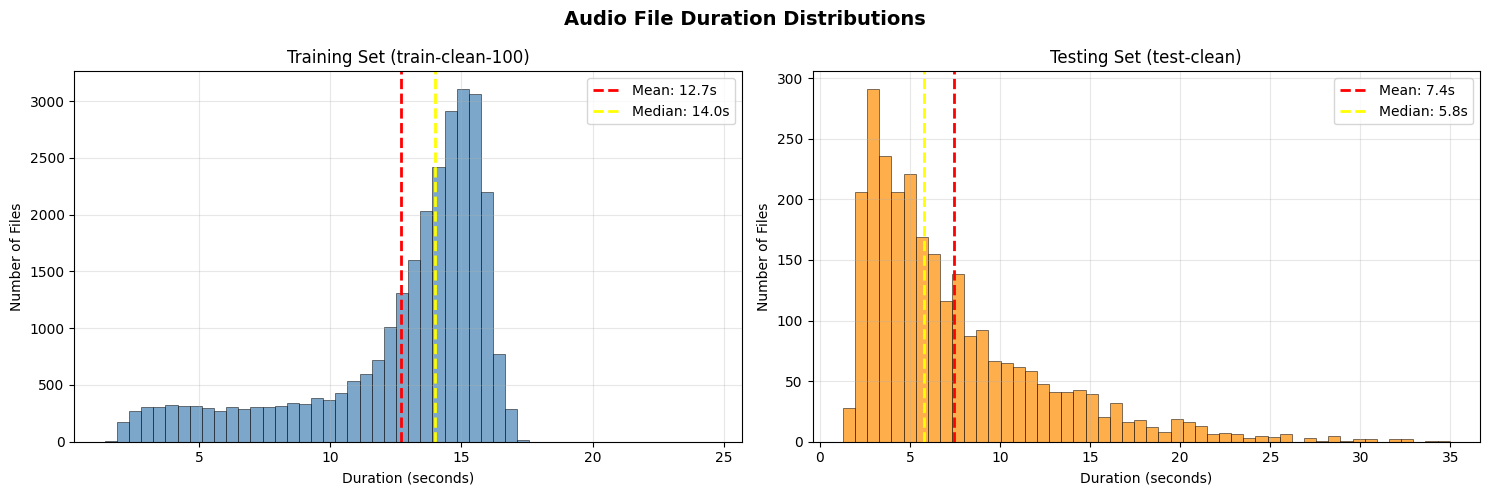

Saved → audio_length_distribution.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Audio File Duration Distributions", fontsize=14, fontweight='bold')

def plot_histogram(ax, data, title, color):
    # Only plot if data exists
    if len(data) > 0:
        ax.hist(data, bins=50, color=color, alpha=0.7, edgecolor='black', linewidth=0.5)
        ax.axvline(np.mean(data), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {np.mean(data):.1f}s')
        ax.axvline(np.median(data), color='yellow', linestyle='dashed', linewidth=2, label=f'Median: {np.median(data):.1f}s')
    
    ax.set_title(title)
    ax.set_xlabel("Duration (seconds)")
    ax.set_ylabel("Number of Files")
    ax.legend()
    ax.grid(True, alpha=0.3)

plot_histogram(axes[0], train_durations, "Training Set (train-clean-100)", "steelblue")
plot_histogram(axes[1], test_durations, "Testing Set (test-clean)", "darkorange")

plt.tight_layout()
plt.savefig("audio_length_distribution.png", dpi=150)
plt.show()
print("Saved → audio_length_distribution.png")

## 6. Crop Window Coverage Analysis

How many files are *shorter* than our chosen crop windows (which means they require zero-padding)?

In [6]:
def print_coverage(data, name):
    if len(data) == 0: return
    
    under_3s = np.sum(data < 3.0) / len(data) * 100
    under_5s = np.sum(data < 5.0) / len(data) * 100
    
    print(f"[{name}]")
    print(f"Files shorter than 3 seconds: {under_3s:.1f}% (Will need padding for 3s model)")
    print(f"Files shorter than 5 seconds: {under_5s:.1f}% (Will need padding for 5s model)\n")

print_coverage(train_durations, "Training Set")
print_coverage(test_durations, "Testing Set")

[Training Set]
Files shorter than 3 seconds: 2.1% (Will need padding for 3s model)
Files shorter than 5 seconds: 6.8% (Will need padding for 5s model)

[Testing Set]
Files shorter than 3 seconds: 14.9% (Will need padding for 3s model)
Files shorter than 5 seconds: 41.6% (Will need padding for 5s model)

